## Proyecto Final.
## Base de datos Avanzados.
## Juliette Ninnie Lazo Vazquez, 371701.

### 1. Conectarse a ElasticSearch

In [1]:
from elasticsearch import Elasticsearch

es = Elasticsearch(
    "https://2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io:443",
    basic_auth=("elastic", "9x1ZrmP3DpKQa5bjIQLRYMmW"),
    verify_certs=False
)

print(es.info())

/opt/anaconda3/lib/python3.11/site-packages/elasticsearch/_sync/client/__init__.py:313: SecurityWarning: Connecting to 'https://2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io:443' using TLS with verify_certs=False is insecure
  _transport = transport_class(


{'name': 'instance-0000000000', 'cluster_name': '2b36632092fb4d9f941ccca51b4cf6d4', 'cluster_uuid': 'AYXxfskiTH-6hGT8_wWBEw', 'version': {'number': '9.2.1', 'build_flavor': 'default', 'build_type': 'docker', 'build_hash': '4ad0ef0e98a2e72fafbd79a19fa5cae2f026117d', 'build_date': '2025-11-06T22:07:39.673130621Z', 'build_snapshot': False, 'lucene_version': '10.3.1', 'minimum_wire_compatibility_version': '8.19.0', 'minimum_index_compatibility_version': '8.0.0'}, 'tagline': 'You Know, for Search'}


/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


### 2 Crear Índice de usuarios

In [4]:
# Índice de usuarios
mapping_usuarios = {
    "mappings": {
        "properties": {
            "user_id": {"type": "keyword"},
            "nombre": {"type": "text"},
            "ciudad": {"type": "keyword"}
        }
    }
}

es.indices.create(index="usuarios", body=mapping_usuarios, ignore=400)

#Indice de amistades
mapping_amistades = {
    "mappings": {
        "properties": {
            "user_1": {"type": "keyword"},
            "user_2": {"type": "keyword"}
        }
    }
}
es.indices.create(index="amistades", body=mapping_amistades, ignore=400)

#Índice de publicaciones (texto no estructurado)
mapping_publicaciones = {
    "mappings": {
        "properties": {
            "user_id": {"type": "keyword"},
            "texto": {"type": "text"},
            "fecha": {"type": "date"},
            "sentimiento": {"type": "float"}
        }
    }
}
es.indices.create(index="publicaciones", body=mapping_publicaciones, ignore=400)

print(" Índices creados correctamente")

/var/folders/9z/s9_3s53s69n8dy5qg725kzxm0000gn/T/ipykernel_42349/425209429.py:12: DeprecationWarning: Passing transport options in the API method is deprecated. Use 'Elasticsearch.options()' instead.
  es.indices.create(index="usuarios", body=mapping_usuarios, ignore=400)
/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/var/folders/9z/s9_3s53s69n8dy5qg725kzxm0000gn/T/ipykernel_42349/425209429.py:23: DeprecationWarning: Passing transport options in the API method is deprecated. Use 'Elasticsearch.options()' instead.
  es.indices.create(index="amistades", body=mapping_amistades, ignore=400)
/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestW

 Índices creados correctamente


/var/folders/9z/s9_3s53s69n8dy5qg725kzxm0000gn/T/ipykernel_42349/425209429.py:36: DeprecationWarning: Passing transport options in the API method is deprecated. Use 'Elasticsearch.options()' instead.
  es.indices.create(index="publicaciones", body=mapping_publicaciones, ignore=400)
/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


### 3. Insertar usuarios

In [5]:
usuarios = [
    {"user_id": "107", "nombre": "Ana", "ciudad": "Madrid"},
    {"user_id": "1684", "nombre": "Luis", "ciudad": "Barcelona"},
    {"user_id": "1912", "nombre": "María", "ciudad": "Valencia"},
    {"user_id": "3437", "nombre": "Carlos", "ciudad": "Bilbao"},
    {"user_id": "0", "nombre": "Lucía", "ciudad": "Sevilla"}
]

for u in usuarios:
    es.index(index="usuarios", document=u)

amistades = [
    {"user_1": "107", "user_2": "1684"},
    {"user_1": "107", "user_2": "1912"},
    {"user_1": "1684", "user_2": "1912"},
    {"user_1": "1912", "user_2": "3437"},
    {"user_1": "0", "user_2": "107"}
]

for a in amistades:
    es.index(index="amistades", document=a)

print(" Usuarios y amistades insertados en Elasticsearch")

/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://url

 Usuarios y amistades insertados en Elasticsearch


/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


### 4. Insertar análisis de sentimiento

In [5]:
from textblob import TextBlob
from datetime import datetime
from deep_translator import GoogleTranslator


publicaciones = [
    {"user_id": "107", "texto": "Hoy visité el museo y me encantó la exposición de arte moderno.", "fecha": datetime(2024, 5, 10)},
    {"user_id": "1684", "texto": "No me gustó la nueva actualización de la app, está lenta y confusa.", "fecha": datetime(2024, 5, 12)},
    {"user_id": "1912", "texto": "Me encanta compartir tiempo con mis amigos los fines de semana.", "fecha": datetime(2024, 5, 15)},
    {"user_id": "3437", "texto": "Hoy fue un día difícil, muchas tareas y poco descanso.", "fecha": datetime(2024, 5, 17)},
    {"user_id": "0", "texto": "Iniciando una nueva semana con energía positiva y metas claras!", "fecha": datetime(2024, 5, 19)}
]

for p in publicaciones:
    texto_en = GoogleTranslator(source='es', target='en').translate(p["texto"])
    p["sentimiento"] = TextBlob(texto_en).sentiment.polarity
    es.index(index="publicaciones", document=p)

print(" Publicaciones insertadas con sentimiento traducido al inglés")

/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://url

 Publicaciones insertadas con sentimiento traducido al inglés


/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


### 5. Consultas en elasticSearch

In [6]:
# Buscar publicaciones que mencionan "museo"
resultado = es.search(index="publicaciones", query={"match": {"texto": "museo"}})
for r in resultado["hits"]["hits"]:
    print(r["_source"])

# Filtrar publicaciones con sentimiento negativo
negativas = es.search(index="publicaciones", query={"range": {"sentimiento": {"lt": 0}}})
print("Publicaciones negativas:")
for r in negativas["hits"]["hits"]:
    print(r["_source"]["texto"], "-->", r["_source"]["sentimiento"])

{'user_id': '107', 'texto': 'Hoy visité el museo y me encantó la exposición de arte moderno.', 'fecha': '2024-05-10T00:00:00', 'sentimiento': 0.0}
{'user_id': '107', 'texto': 'Hoy visité el museo y me encantó la exposición de arte moderno.', 'fecha': '2024-05-10T00:00:00', 'sentimiento': 0.44999999999999996}
Publicaciones negativas:
No me gustó la nueva actualización de la app, está lenta y confusa. --> -0.15454545454545457
Hoy fue un día difícil, muchas tareas y poco descanso. --> -0.0625


/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


#### sentimiento global

In [7]:
promedio = es.search(
    index="publicaciones",
    aggs={"avg_sentimiento": {"avg": {"field": "sentimiento"}}},
    size=0
)
print("Sentimiento promedio:", promedio["aggregations"]["avg_sentimiento"]["value"])

Sentimiento promedio: 0.08551136255264283


/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


### 6. Integracion de red 

In [8]:
import networkx as nx

# Consultamos todas las amistades
amistades_docs = es.search(index="amistades", query={"match_all": {}}, size=1000)["hits"]["hits"]

G = nx.Graph()
for a in amistades_docs:
    u1 = a["_source"]["user_1"]
    u2 = a["_source"]["user_2"]
    G.add_edge(u1, u2)

print(f"Número de nodos: {G.number_of_nodes()}")
print(f"Número de aristas: {G.number_of_edges()}")

# Calcular centralidad
centralidad = nx.degree_centrality(G)
top_5 = sorted(centralidad.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 usuarios centrales:")
for u, c in top_5:
    print(f"Usuario {u} → Centralidad: {c:.4f}")

Número de nodos: 5
Número de aristas: 5
Top 5 usuarios centrales:
Usuario 107 → Centralidad: 0.7500
Usuario 1912 → Centralidad: 0.7500
Usuario 1684 → Centralidad: 0.5000
Usuario 3437 → Centralidad: 0.2500
Usuario 0 → Centralidad: 0.2500


/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


### 7. Añadir imagenes 

In [10]:
imagenes = [
    {"user_id": "107", "url": "https://picsum.photos/id/107/200/200"},
    {"user_id": "1684", "url": "https://picsum.photos/id/1684/200/200"},
    {"user_id": "1912", "url": "https://picsum.photos/id/1912/200/200"}
]

for img in imagenes:
    es.index(index="imagenes", document=img)

print(" Imágenes simuladas agregadas")

/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


 Imágenes simuladas agregadas


/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


### Ver qué datos están dentro de cada índice

In [2]:
# Usuarios
print("Usuarios:")
res = es.search(index="usuarios", query={"match_all": {}}, size=10)
for r in res["hits"]["hits"]:
    print(r["_source"])

# Publicaciones
print("\nPublicaciones:")
res = es.search(index="publicaciones", query={"match_all": {}}, size=10)
for r in res["hits"]["hits"]:
    print(r["_source"])

# Imágenes
print("\nImágenes:")
res = es.search(index="imagenes", query={"match_all": {}}, size=10)
for r in res["hits"]["hits"]:
    print(r["_source"])

Usuarios:
{'user_id': '107', 'nombre': 'Ana', 'ciudad': 'Madrid'}
{'user_id': '1684', 'nombre': 'Luis', 'ciudad': 'Barcelona'}
{'user_id': '1912', 'nombre': 'María', 'ciudad': 'Valencia'}
{'user_id': '3437', 'nombre': 'Carlos', 'ciudad': 'Bilbao'}
{'user_id': '0', 'nombre': 'Lucía', 'ciudad': 'Sevilla'}

Publicaciones:


/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


{'user_id': '107', 'texto': 'Hoy visité el museo y me encantó la exposición de arte moderno.', 'fecha': '2024-05-10T00:00:00', 'sentimiento': 0.0}
{'user_id': '1684', 'texto': 'No me gustó la nueva actualización de la app, está lenta y confusa.', 'fecha': '2024-05-12T00:00:00', 'sentimiento': 0.0}
{'user_id': '1912', 'texto': 'Me encanta compartir tiempo con mis amigos los fines de semana.', 'fecha': '2024-05-15T00:00:00', 'sentimiento': 0.0}
{'user_id': '3437', 'texto': 'Hoy fue un día difícil, muchas tareas y poco descanso.', 'fecha': '2024-05-17T00:00:00', 'sentimiento': 0.0}
{'user_id': '0', 'texto': 'Iniciando una nueva semana con energía positiva y metas claras!', 'fecha': '2024-05-19T00:00:00', 'sentimiento': 0.0}

Imágenes:
{'user_id': '107', 'url': 'https://picsum.photos/id/107/200/200'}
{'user_id': '1684', 'url': 'https://picsum.photos/id/1684/200/200'}
{'user_id': '1912', 'url': 'https://picsum.photos/id/1912/200/200'}


/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


### Calcular y visualizar el promedio de sentimiento global

In [9]:
promedio = es.search(
    index="publicaciones",
    aggs={"avg_sentimiento": {"avg": {"field": "sentimiento"}}},
    size=0
)
print("Sentimiento promedio global:", promedio["aggregations"]["avg_sentimiento"]["value"])

Sentimiento promedio global: 0.08551136255264283


/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


### Visualizar el sentimiento por usuario

/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


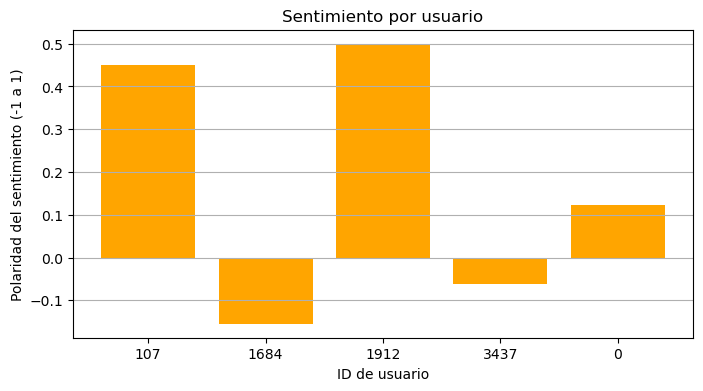

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Obtener los documentos de publicaciones
res = es.search(index="publicaciones", query={"match_all": {}}, size=20)
data = [doc["_source"] for doc in res["hits"]["hits"]]
df = pd.DataFrame(data)

# Si el valor 'sentimiento' existe:
if "sentimiento" in df.columns:
    plt.figure(figsize=(8,4))
    plt.bar(df["user_id"], df["sentimiento"], color="orange")
    plt.title("Sentimiento por usuario")
    plt.xlabel("ID de usuario")
    plt.ylabel("Polaridad del sentimiento (-1 a 1)")
    plt.grid(axis='y')
    plt.show()
else:
    print("No se encontró el campo 'sentimiento' en las publicaciones.")

### Visualizar la red de amistades

/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


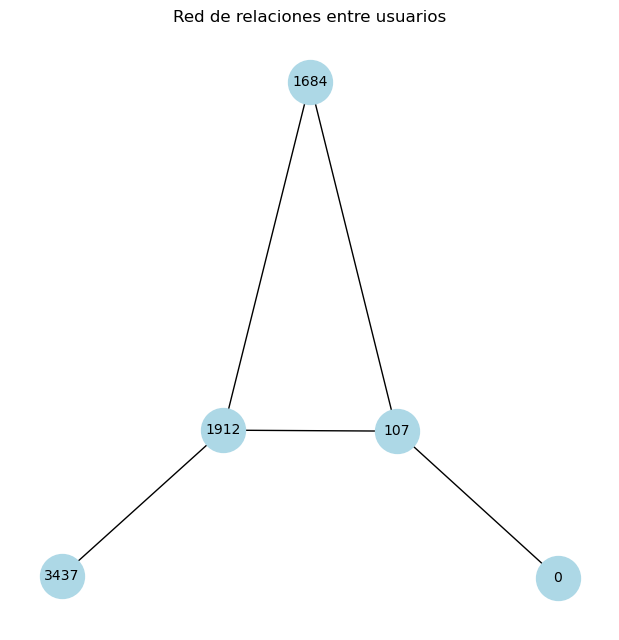

In [11]:
import matplotlib.pyplot as plt
import networkx as nx

# Recuperar amistades desde Elasticsearch
amistades_docs = es.search(index="amistades", query={"match_all": {}}, size=1000)["hits"]["hits"]

# Crear grafo
G = nx.Graph()
for a in amistades_docs:
    u1 = a["_source"]["user_1"]
    u2 = a["_source"]["user_2"]
    G.add_edge(u1, u2)

# Dibujar red
plt.figure(figsize=(6,6))
nx.draw(G, with_labels=True, node_color='lightblue', node_size=1000, font_size=10, font_color='black')
plt.title("Red de relaciones entre usuarios")
plt.show()

### Integrar sentimiento con centralidad

In [12]:
# Obtener sentimientos promedio por usuario
res = es.search(
    index="publicaciones",
    aggs={"por_usuario": {"terms": {"field": "user_id"}, "aggs": {"avg_sent": {"avg": {"field": "sentimiento"}}}}},
    size=0
)
sent_dict = {b["key"]: b["avg_sent"]["value"] for b in res["aggregations"]["por_usuario"]["buckets"]}

# Calcular centralidad
centralidad = nx.degree_centrality(G)
df_res = pd.DataFrame([
    {"user_id": u, "centralidad": c, "sentimiento": sent_dict.get(u, None)}
    for u, c in centralidad.items()
])

display(df_res)

/opt/anaconda3/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '2b36632092fb4d9f941ccca51b4cf6d4.us-central1.gcp.cloud.es.io'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


,user_id,centralidad,sentimiento
0,107,0.75,0.225000
1,1684,0.50,-0.077273
2,1912,0.75,0.250000
3,3437,0.25,-0.031250
4,0,0.25,0.061080


### Exportar resultados a un CSV

In [13]:
df_res.to_csv("resultados_elastic.csv", index=False)